In [3]:
import numpy as np
import matplotlib.pyplot as plt
from fno_definitions import*
import torch

# Literature

1) FNO for differential equations (original paper)
https://arxiv.org/abs/2010.08895

2) General introduction, complete
https://arxiv.org/abs/2512.01421v2, see NeuralOperator 2.0.0 library

# Minor stuff and trials

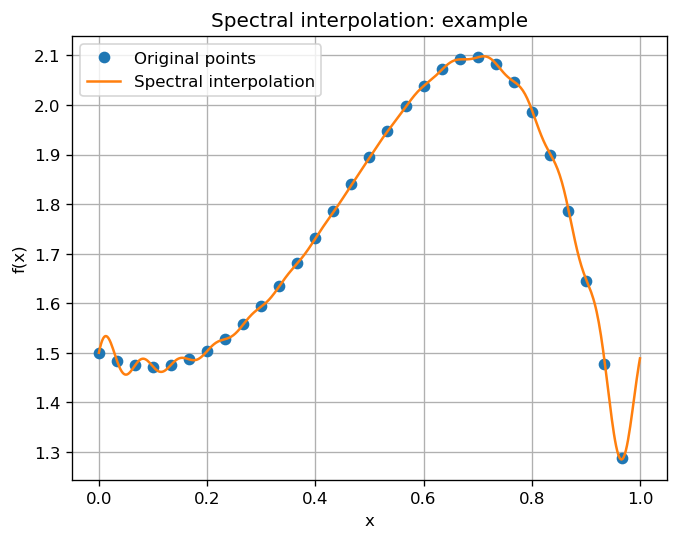

In [2]:
# test: spectral interpolation of 1d vector

def spectral_interpolation(signal: torch.tensor, M: int) -> torch.Tensor:

    """Gives the spectral interpolation of a 1d array on M points. Following 2), page 16"""
    N = len(signal) 
    fft_coeffs = torch.fft.fft(signal)
    pos_freqs = fft_coeffs[:N//2 + 1]
    neg_freqs = fft_coeffs[N//2 + 1:]

    fft_coeffs_padded = torch.cat([pos_freqs, torch.zeros(M - N), neg_freqs])

    return (torch.fft.ifft(fft_coeffs_padded).real)*M/N # the interpolated signal, scale by M/N to preserve energy


f = lambda x: torch.sin(3*x**2) + 0.5*torch.cos(torch.sqrt(x)) + 1.0 - x/3.

N = 30
xx = torch.linspace(0, 1, N+1)[:-1] # data x_n, n from 0 to N-1 

M_eval = 500

plt.figure(dpi = 120)
plt.title('Spectral interpolation: example')
plt.grid()
plt.xlabel('x')
plt.ylabel('f(х)')
plt.plot(xx, f(xx), 'o', label = 'Original points')
plt.plot(torch.linspace(0, 1, M_eval), spectral_interpolation(f(xx), M_eval), label = 'Spectral interpolation')
plt.legend()
plt.show()

# First FNO trial (with definition from `fno_definitions.py`)

In [ ]:
# a 64x64 grid with 2000 test functions nearly eats up all of my computer's RAM (16BG)
# for the moment trying on a smaller 48x48 grid with 1000 test functions

# start with something reasonably small
fno_trial = FNO_v1(n_modes = [8,8], hidden_dimension = 24, lr = 0.001)

# note that compared to the way I set up the deepONets, here the X and Y (input and output) arrays are kept 2d and not flattened with .ravel().
# this is because I need to distinguish the two directions for the 2d fft to be applicable

# the solutions in the dataset are computed on the [-1, 1] 2d-square, on a 64x64 grid
fno_trial.fit_from_npz('data/dataset_for_fno.npz', 250)

Y std across samples: 0.04481997713446617
Y std across points:  0.026096409186720848
Epoch [10/250], Loss: 0.0026, Loss eval: 0.0025
prediction std across samples: 0.0153989028185606
prediction std across points: 0.0013510705903172493
Epoch [20/250], Loss: 0.0021, Loss eval: 0.0020
prediction std across samples: 0.02600661851465702
prediction std across points: 0.0020394634921103716
Epoch [30/250], Loss: 0.0020, Loss eval: 0.0020
prediction std across samples: 0.022324213758111
prediction std across points: 0.0017008142312988639
Epoch [40/250], Loss: 0.0020, Loss eval: 0.0019
prediction std across samples: 0.02570357546210289
prediction std across points: 0.0013259078841656446
Epoch [50/250], Loss: 0.0019, Loss eval: 0.0019
prediction std across samples: 0.026258740574121475
prediction std across points: 0.0013370539527386427
Epoch [60/250], Loss: 0.0019, Loss eval: 0.0019
prediction std across samples: 0.026603002101182938
prediction std across points: 0.001351845683529973
Epoch [70/2

KeyboardInterrupt: 

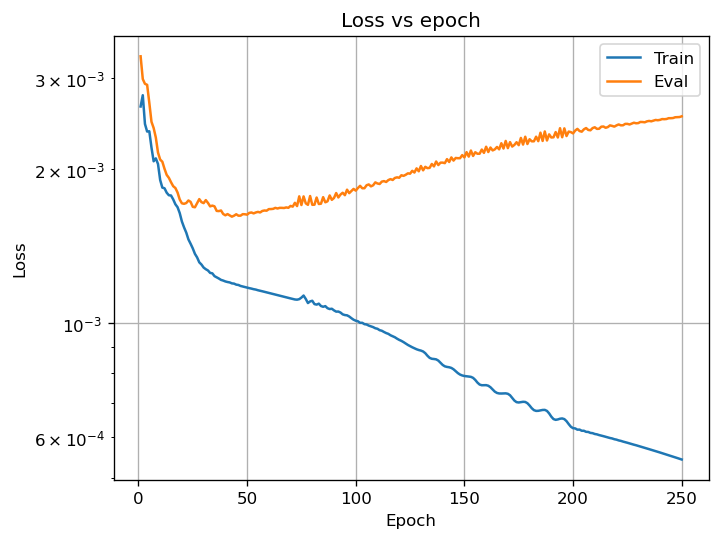

/var/folders/59/t4572hz13tg2y_6ql18g7cvw0000gn/T/ipykernel_31059/3426932002.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


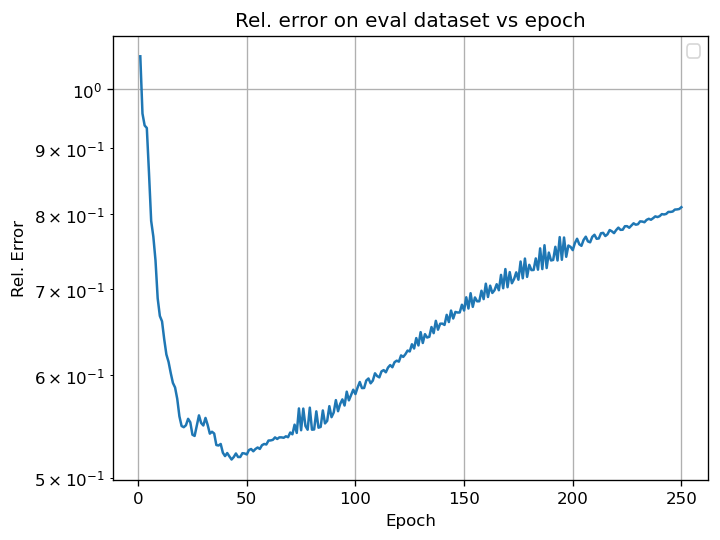

In [3]:
plt.figure(dpi = 120)
plt.title("Loss vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.semilogy(fno_trial.epochs, fno_trial.losses, label = "Train")
plt.semilogy(fno_trial.epochs, fno_trial.losses_eval, label = "Eval")
plt.legend()
plt.grid()
plt.show()

plt.figure(dpi = 120)
plt.title("Rel. error on eval dataset vs epoch")
plt.xlabel('Epoch')
plt.ylabel("Rel. Error")
plt.semilogy(fno_trial.epochs, fno_trial.rel_errors_eval)
plt.legend()
plt.grid()
plt.show()

In [ ]:
# the VERY low standard variation across points tell me the model gives some kind of constant function. this is a major issues that needs fixing
# also, the model is very slow and its speed should be improved. to do: use real fft, avoid fft shift

# to try: sinusoidal embeddings (see literature), skip connections
# - apply normalizations
# - add coordinates as input. so from input dimension 1 we go to input dimension 3

# use Sobolev loss ?


# Trying with FNO from neuralop.models (NeuralOperator library)

https://github.com/neuraloperator/neuraloperator

In [1]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
from neuralop.models import FNO
from neuralop import Trainer
from neuralop.training import AdamW
from neuralop import LpLoss, H1Loss
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # need this for CPU fallback is mps support for somme fft-related operations is incomplete
from neuralop.data.datasets.tensor_dataset import TensorDataset

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# first load the training an test data
train_data = torch.load("data/poisson_train_64.pt")
test_data = torch.load("data/poisson_test_64.pt")

# define the train and test dataset with TensorDataset from the neuralop library
# neuralop expects each batch to be a dictionary with keys 'x', 'y'
train_dataset = TensorDataset(x=train_data['x'], y=train_data['y'])
test_dataset  = TensorDataset(x=test_data['x'], y=test_data['y'])

# define the train and test loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

# define the model
model = FNO(n_modes=(8, 8), hidden_channels=24, in_channels=1, out_channels=1).to(device)

# define the optimizer and the scheduler
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

# define the losses
l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

# for training use H1 Sobolev norm loss (H1loss), for eval also track the Lp loss
train_loss = h1loss
eval_losses = {'l2': l2loss, 'h1': h1loss}

# define the trainer
trainer = Trainer(
    model=model,
    n_epochs=30,
    device=device,
    wandb_log=False,
    eval_interval=3,
    use_distributed=False,
    verbose=True
)

# now do the training
history = trainer.train(
    train_loader=train_loader,
    test_loaders={'test': test_loader},
    optimizer=optimizer,
    scheduler=scheduler,
    regularizer=False,
    training_loss=train_loss,
    eval_losses=eval_losses
)


print(history.keys())  # check exact key names first: they vary by version

# now plot the errors as a function of the epoch
plt.plot(history['train_err'], label='train')
if 'test_h1' in history:
    plt.plot(history['test_h1'], label='test (h1)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.yscale('log')
plt.legend()
plt.show()

Training on 800 samples
Testing on [200] samples         on resolutions ['test'].


/opt/homebrew/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1790: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)
/Users/filippo/neuraloperator/neuralop/layers/spectral_convolution.py:443: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 24, 64, 33]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/Users/filippo/neuraloperator/neuralop/layers/spectral_convolution.py:559: UserWarning: An output with one or more elements was resized since it had shape [],

Raw outputs of shape torch.Size([16, 1, 64, 64])


/Users/filippo/neuraloperator/neuralop/training/trainer.py:536: UserWarning: H1Loss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  loss += training_loss(out, **sample)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [16, 24, 64, 33]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[0] time=6.99, avg_loss=nan, train_err=nan


/Users/filippo/neuraloperator/neuralop/training/trainer.py:581: UserWarning: LpLoss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  val_loss = loss(out, **sample)
/Users/filippo/neuraloperator/neuralop/layers/spectral_convolution.py:443: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [8, 24, 64, 33]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  x = torch.fft.rfftn(x, norm=self.fft_norm, dim=fft_dims)
/Users/filippo/neuraloperator/neuralop/layers/spectral_convolution.py:559: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the

Eval: test_l2=nan, test_h1=nan
[3] time=4.11, avg_loss=nan, train_err=nan
Eval: test_l2=nan, test_h1=nan


KeyboardInterrupt: 

**Comments**

Using the `neuraloperator` library, the steps are very slow - and they often yield nan losses (I still have to understand why - maybe need normalizing)?
Work still in progress... for now not working